In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib inline
from arch import arch_model
from statsmodels.tsa.stattools import adfuller


In [2]:
import yfinance as yf
gse = yf.download("FAB", start="2020-01-01", end="2025-01-01")
gse

C:\Users\K.M.A\AppData\Local\Temp\ipykernel_16932\2721731720.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gse = yf.download("FAB", start="2020-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,FAB,FAB,FAB,FAB,FAB
Date,,,,,
2020-01-02,51.920151,52.215914,51.821562,52.215914,8600
2020-01-03,51.696075,51.731927,51.570600,51.660224,9800
2020-01-06,51.669193,51.722966,51.579566,51.579566,11300
2020-01-07,51.624382,51.705045,51.516832,51.705045,3900
2020-01-08,51.669193,51.803630,51.579566,51.687115,4800
...,...,...,...,...,...
2024-12-24,81.415039,81.415039,81.119876,81.119876,1400
2024-12-26,81.631485,81.631485,80.991970,80.991970,1600


In [3]:
gse.columns

MultiIndex([( 'Close', 'FAB'),
            (  'High', 'FAB'),
            (   'Low', 'FAB'),
            (  'Open', 'FAB'),
            ('Volume', 'FAB')],
           names=['Price', 'Ticker'])

In [4]:
close=gse[['Close']]
close.head()

Price,Close
Ticker,FAB
Date,
2020-01-02,51.920151
2020-01-03,51.696075
2020-01-06,51.669193
2020-01-07,51.624382
2020-01-08,51.669193


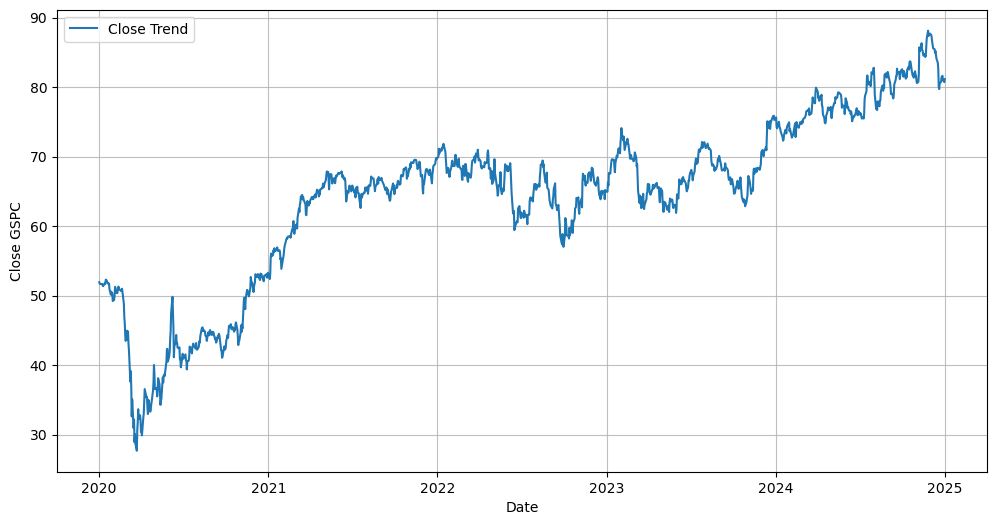

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(close,label='Close Trend')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Close GSPC')
plt.grid(True,alpha=0.8)
plt.show()

#### The accompanying chart illustrates a pronounced upward trajectory in the closing price, which appreciated from approximately GHS 51.92 at the beginning of 2020 to GHS 81.15 by the end of 2024. In 2020, the stock commenced the year at this initial value but experienced a significant decline to roughly GHS 27 amid the onset of the COVID-19 pandemic. However, it demonstrated resilience by recovering its losses before the year concluded. Throughout the subsequent years, the stock encountered volatility attributed to the instability of the Ghanaian Cedi and broader economic pressures. Despite these persistent challenges, the overall trend remained robust, culminating in the substantial growth observed over the five-year period


In [6]:
returns=100*np.log(close).diff().dropna()

In [7]:
returns.head()

Price,Close
Ticker,FAB
Date,
2020-01-03,-0.432511
2020-01-06,-0.052014
2020-01-07,-0.086765
2020-01-08,0.086765
2020-01-09,-0.052071


In [8]:
returns.describe()

Price,Close
Ticker,FAB
count,1257.000000
mean,0.035528
std,1.708448
min,-12.512887
25%,-0.716181
50%,0.027816
75%,0.854553
max,10.299388


#### The descriptive analysis above reveal a modest positive average daily return mean return of 0.035528, and standard deviation of 1.708448, indicating moderate volatility. 

In [9]:
returns.skew()

Price  Ticker
Close  FAB      -0.619448
dtype: float64

#### The skewness value of -0.619 indicates negative skew, meaning the distribution has a longer left tail. Negative skew commonly indicates that the thick tail is on the left side of the distribution, making highly negative returns more likely.

In [10]:
returns.kurtosis()

Price  Ticker
Close  FAB       10.438667
dtype: float64

#### The kurtosis value of 10.439 confirms the presence of "heavy tails" or "fat tails". This combination of negative skew and high kurtosis is characteristic of financial returns and justifies the use of GARCH models with non-normal distributions.

In [11]:
dftest = adfuller(returns, autolag = 'AIC')
dftest


(np.float64(-10.662877282037131),
 np.float64(4.361477540998361e-19),
 8,
 1248,
 {'1%': np.float64(-3.4356006420838963),
  '5%': np.float64(-2.8638586845641063),
  '10%': np.float64(-2.5680044958343604)},
 np.float64(4775.122726348904))

#### The Augmented Dickey-Fuller (ADF) test was performed on the return series to check for stationarity. The ADF test examines whether a time series has a unit root (non-stationary) against the alternative of stationarity . The test statistic of -10.663 with a p-value of 4.36e-19 strongly rejects the null hypothesis of a unit root, confirming that the return series is stationary. This is expected for financial returns and is necessary for GARCH modeling, as non-stationary data can lead to spurious regression results.

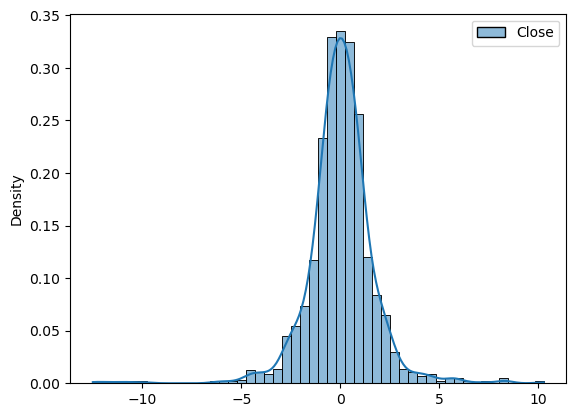

In [12]:
import seaborn as sns
plt.figure()
sns.histplot(returns,kde=True,bins=50,stat='density',alpha=0.5,color='blue',edgecolor='black')
plt.show()


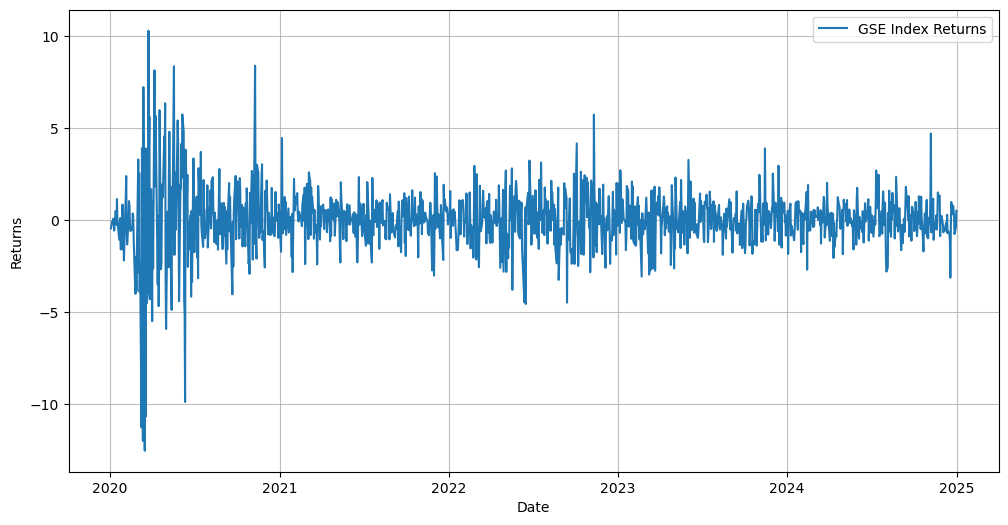

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(returns,label='GSE Index Returns')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Returns')
plt.grid(True,alpha=0.8)
plt.show()

### Normal GARCH

In [14]:
model_norm=arch_model(returns,vol="Garch",p=1,o=0,q=1,dist="Normal")
res=model_norm.fit(update_freq=5)

Iteration:      5,   Func. Count:     34,   Neg. LLF: 2490.785402439664
Iteration:     10,   Func. Count:     60,   Neg. LLF: 2134.463573235587
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2134.463571479992
            Iterations: 12
            Function evaluations: 69
            Gradient evaluations: 12


In [15]:
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:       ('Close', 'FAB')   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2134.46
Distribution:                  Normal   AIC:                           4276.93
Method:            Maximum Likelihood   BIC:                           4297.47
                                        No. Observations:                 1257
Date:                Sun, Feb 15 2026   Df Residuals:                     1256
Time:                        00:04:35   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0506  3.115e-02      1.624      0.104 [-1.046e-02,  0.112]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1205  4.442e-02      2.712  6.690e-03 [3.340e-02,  0.208]
alpha[1]       0.1765  4.979e-02      3.546  3.918e-04 [7.895e-02,  0.274]
beta[1]        0.7700  5.902e-02     13.046  6.734e-39   [  0.654,  0.886]
==========================================================================

Covariance estimator: robust
"""

#### This model assumes normally distributed errors. All volatility parameters (omega, alpha[1], beta[1]) are statistically significant. The persistence (alpha + beta) is approximately 0.9465, indicating high volatility persistence 

### Student's T-Distribution

In [16]:
model_t = arch_model(returns, vol='Garch', p=1, q=1, dist='t')
res_t = model_t.fit(update_freq=5)

Iteration:      5,   Func. Count:     40,   Neg. LLF: 2116.2338098888326
Iteration:     10,   Func. Count:     69,   Neg. LLF: 2116.165205305171
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2116.1652053051694
            Iterations: 10
            Function evaluations: 69
            Gradient evaluations: 10


In [17]:
res_t.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:             ('Close', 'FAB')   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2116.17
Distribution:      Standardized Student's t   AIC:                           4242.33
Method:                  Maximum Likelihood   BIC:                           4268.01
                                              No. Observations:                 1257
Date:                      Sun, Feb 15 2026   Df Residuals:                     1256
Time:                              00:04:35   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0535  3.069e-02      1.745  8.104e-02 [-6.608e-03,  0.114]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0933  4.478e-02      2.084  3.718e-02 [5.542e-03,  0.181]
alpha[1]       0.1487  5.013e-02      2.967  3.005e-03 [5.049e-02,  0.247]
beta[1]        0.8099  6.380e-02     12.695  6.273e-37   [  0.685,  0.935]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             7.8144      1.592      4.910  9.130e-07 [  4.695, 10.934]
========================================================================

Covariance estimator: robust
"""

#### This model accounts for heavy tails through the degrees of freedom parameter (nu = 7.8144, highly significant). The AIC (4242.33) and BIC (4268.01) are both lower than the normal GARCH, indicating better model fit. The persistence (0.9586) is slightly higher than the normal model.

### Skewed Student's T

In [18]:
model_skewt = arch_model(returns, vol='Garch', p=1, q=1, dist='skewt')
res_skewt = model_skewt.fit(update_freq=5)


Iteration:      5,   Func. Count:     46,   Neg. LLF: 54060.19089294065
Iteration:     10,   Func. Count:     83,   Neg. LLF: 2115.3662158250136
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2115.3662147646264
            Iterations: 12
            Function evaluations: 96
            Gradient evaluations: 12


In [19]:
res_skewt.summary() 

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                           
=========================================================================================
Dep. Variable:                  ('Close', 'FAB')   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                 GARCH   Log-Likelihood:               -2115.37
Distribution:      Standardized Skew Student's t   AIC:                           4242.73
Method:                       Maximum Likelihood   BIC:                           4273.55
                                                   No. Observations:                 1257
Date:                           Sun, Feb 15 2026   Df Residuals:                     1256
Time:                                   00:04:36   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0424  3.158e-02      1.342      0.179 [-1.950e-02,  0.104]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0850  4.261e-02      1.996  4.595e-02 [1.531e-03,  0.169]
alpha[1]       0.1438  4.835e-02      2.974  2.941e-03 [4.903e-02,  0.239]
beta[1]        0.8189  6.143e-02     13.330  1.542e-40   [  0.698,  0.939]
                               Distribution                               
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
eta            7.8558      1.621      4.847  1.252e-06   [  4.679, 11.032]
lambda        -0.0524  4.313e-02     -1.214      0.225 [ -0.137,3.217e-02]
==========================================================================

Covariance estimator: robust
"""

#### The Skewed Student's t GARCH model accounts for both heavy tails and asymmetry. The skewness parameter (lambda = -0.0524) confirms the negative skew observed in the data but is not statistically significant (p = 0.225). The AIC (4242.73) and BIC (4273.55) are slightly higher than the symmetric Student's t model.

### GED

In [20]:
model_ged = arch_model(returns, vol='Garch', p=1, q=1, dist='ged')
res_ged = model_ged.fit(update_freq=5)


Iteration:      5,   Func. Count:     40,   Neg. LLF: 87222.21453412175
Iteration:     10,   Func. Count:     72,   Neg. LLF: 2119.18217525376
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2119.1821491579085
            Iterations: 12
            Function evaluations: 84
            Gradient evaluations: 12


In [21]:
res_ged.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                            
==========================================================================================
Dep. Variable:                   ('Close', 'FAB')   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:               -2119.18
Distribution:      Generalized Error Distribution   AIC:                           4248.36
Method:                        Maximum Likelihood   BIC:                           4274.05
                                                    No. Observations:                 1257
Date:                            Sun, Feb 15 2026   Df Residuals:                     1256
Time:                                    00:04:36   Df Model:                            1
                                 Mean Model                                
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.0523  3.192e-02      1.639      0.101 [-1.026e-02,  0.115]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1077  4.458e-02      2.416  1.570e-02 [2.033e-02,  0.195]
alpha[1]       0.1635  4.913e-02      3.327  8.767e-04 [6.719e-02,  0.260]
beta[1]        0.7877  6.132e-02     12.847  8.943e-38   [  0.668,  0.908]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             1.4899  8.550e-02     17.425  5.360e-68 [  1.322,  1.657]
========================================================================

Covariance estimator: robust
"""

#### The Generalized Error Distribution model shows a shape parameter (nu = 1.4899) significantly different from 2 (which would indicate normality). The AIC (4248.36) and BIC (4274.05) are higher than the Student's t models.

### Model Selection   
#### Based on both AIC and BIC criteria, the Student's t GARCH(1,1) model provides the best fit for the FAB return data.The model's persistence parameter (alpha + beta = 0.9586) indicates that volatility shocks decay slowly when volatility spikes occur, they take considerable time to return to normal levels. This is consistent with the volatility clustering observed in the return plot.


### INDEX NUMBERS
#### SB/FIN/22/0183
#### SB/FIN/22/0043
#### SB/FIN/22/0091
#### SB/FIN/22/0038
#### SB/FIN/22/0101
#### SB/FIN/22/0072
#### SB/FIN/22/0150
#### SB/FIN/22/0049
#### SB/FIN/22/0073